In [1]:
import anndata as ad
import scanpy as sc

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
import math
from scipy.stats import pearsonr

import squidpy as sq
import seaborn as sns

In [30]:
# Load data
rna = ad.read_h5ad("../../data/train_rna.h5ad")
pro = ad.read_h5ad("../../data/train_pro.h5ad")
valid_rna = ad.read_h5ad("../../data/valid_rna.h5ad")
test_rna = ad.read_h5ad("../../data/test_rna.h5ad")

# Counts of columns and rows
print(f"RNA: {rna.n_obs} bins × {rna.n_vars} genes")
print(f"Protein: {pro.n_obs} bins × {pro.n_vars} markers")
print(f"RNA: {valid_rna.n_obs} bins × {valid_rna.n_vars} genes")
print(f"RNA: {test_rna.n_obs} bins × {test_rna.n_vars} genes")


RNA: 166186 bins × 18085 genes
Protein: 166186 bins × 44 markers
RNA: 8786 bins × 18085 genes
RNA: 84386 bins × 18085 genes


In [33]:
# Copy spatial coordinates from RNA to protein data
pro.obs["array_row"] = rna.obs["array_row"].values
pro.obs["array_col"] = rna.obs["array_col"].values
pro.obs["pxl_row_in_fullres"] = rna.obs["pxl_row_in_fullres"].values
pro.obs["pxl_col_in_fullres"] = rna.obs["pxl_col_in_fullres"].values


In [43]:
rna_pr = ad.read_h5ad("../../data/rna_train_preprocessed.h5ad")
pro_pr = ad.read_h5ad("../../data/pro_train_preprocessed.h5ad")
valid_rna_pr = ad.read_h5ad("../../data/rna_val_preprocessed.h5ad")

# EDA

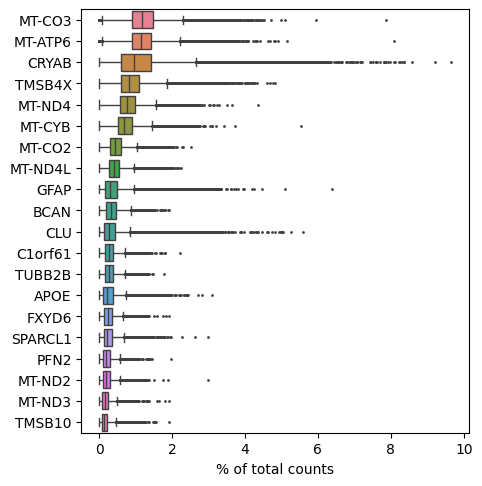

In [4]:
# Highest gene expression (Fraction of counts assigned to each gene over all cells)
sc.pl.highest_expr_genes(rna, n_top=20)   # top expressed genes

## Spatial distribution

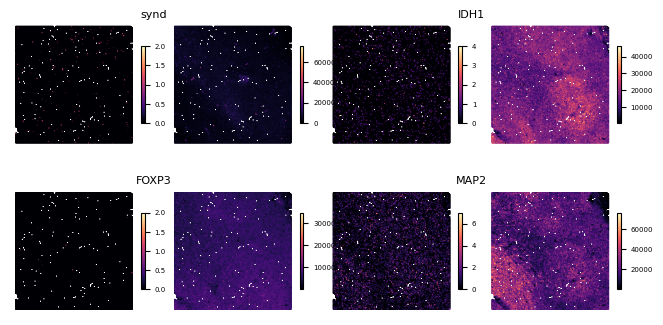

In [21]:
pairs = [
    ("SDC1", "synd"),
    ("FOXP3", "FOXP3"),
    ("IDH1", "IDH1"),
    ("MAP2", "MAP2")
]

# ("OLIG2", "OLIG2"), ("MSH6", "MSH6"), ("CD14", "CD14"), ("ICOS", "ICOS")

pairs_per_group = 2                     # rows per column-block
n_groups = math.ceil(len(pairs) / pairs_per_group)
n_rows = pairs_per_group
n_cols = n_groups * 2                    # each pair = RNA col + protein col

panel_w, panel_h = 1.6, 1.6              # size per scatter panel (inches)
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(panel_w * n_cols, panel_h * n_rows),
    squeeze=False
)

plt.subplots_adjust(wspace=0.15, hspace=0.3, left=0.02, right=0.98, top=0.94, bottom=0.02)

for i, (rna_gene, pro_marker) in enumerate(pairs):
    group = i // pairs_per_group         # which column-block (0 or 1)
    row = i % pairs_per_group            # row within that block
    col_offset = group * 2               # 0 or 2

    for col, (adata, feature) in enumerate(zip([rna, pro], [rna_gene, pro_marker])):
        ax = axes[row, col_offset + col]
        idx = list(adata.var_names).index(feature)
        expr = adata.X[:, idx]
        if sp.issparse(expr):
            expr = expr.toarray().flatten()

        sc_plot = ax.scatter(
            adata.obs["array_col"], adata.obs["array_row"],
            c=expr, s=0.8, cmap="magma", linewidths=0
        )
        cbar = plt.colorbar(sc_plot, ax=ax, shrink=0.6, pad=0.02, fraction=0.046)
        cbar.ax.tick_params(labelsize=5)
        ax.set_aspect("equal")
        ax.axis("off")

    pos_left = axes[row, col_offset].get_position()
    pos_right = axes[row, col_offset + 1].get_position()
    x_center = (pos_left.x0 + pos_right.x1) / 2
    fig.text(
        x_center, pos_left.y1 + 0.003, pro_marker,
        ha="center", va="bottom", fontsize=8
    )

plt.savefig("spatial_comparison_4.png", dpi=150, bbox_inches="tight")
plt.show()

## RNA protein relationship

In [4]:
# Check which protein markers have a matching gene name in rna data

protein_names = pro.var_names.tolist()
rna_names = rna.var_names.tolist()

matched = [p for p in protein_names if p in rna.var_names]
unmatched = [p for p in protein_names if p not in rna.var_names]

print("in both:", matched)
print("\nin protein only:", unmatched)

in both: ['FOXP3', 'CXCL13', 'OLIG2', 'CXCR5', 'CD68', 'CD44', 'MSH6', 'GFAP', 'CD47', 'CD74', 'IDH1', 'MPO', 'TOX', 'CD4', 'MAP2', 'MGMT', 'CD38', 'CD14', 'ICOS']

in protein only: ['synd', 'CD16', 'CD31', 'Ki67', 'HLA-A', 'PD-L1', 'PSD95', 'CD20', 'SMA', 'CD23', 'SYNA', 'Podoplanin', 'Vimentin', 'SIRP', 'Granzyme B', 'CD45', 'CD21', 'FIBR', 'C-KIT', 'CD3e', 'PD-1', 'PDGFR', 'CD8', 'HLA-DR', 'Granzyme K']


In [5]:
# potential matches for proteins that don't have exact name matches in rna (protein:rna)
matches = {'synd': 'SDC1', 'CD16': 'FCGR3A', 'Ki67': 'MKI67',
    'PD-L1': 'CD274', 'PSD95': 'DLG4', 'CD20': 'MS4A1',
    'SMA': 'ACTA2', 'CD23': 'FCER2', 'SYNA': 'SYN1',
    'Podoplanin': 'PDPN', 'Vimentin': 'VIM', 'SIRP': 'SIRPA',
    'Granzyme B': 'GZMB', 'CD45': 'PTPRC', 'CD21': 'CR2',
    'FIBR': 'FN1', 'C-KIT': 'KIT', 'CD3e': 'CD3E',
    'PD-1': 'PDCD1', 'PDGFR': 'PDGFRA', 'CD8': 'CD8A',
    'Granzyme K': 'GZMK'}

In [6]:
# list of all proteins that have matches in rna
rna_protein_pairs = []

# exact name matches
for protein in matched:
    rna_protein_pairs.append((protein, protein))

# non-exact matches
for key, value in matches.items():
    rna_protein_pairs.append((key, value))

In [7]:
print(rna_protein_pairs)
print(len(rna_protein_pairs))

[('FOXP3', 'FOXP3'), ('CXCL13', 'CXCL13'), ('OLIG2', 'OLIG2'), ('CXCR5', 'CXCR5'), ('CD68', 'CD68'), ('CD44', 'CD44'), ('MSH6', 'MSH6'), ('GFAP', 'GFAP'), ('CD47', 'CD47'), ('CD74', 'CD74'), ('IDH1', 'IDH1'), ('MPO', 'MPO'), ('TOX', 'TOX'), ('CD4', 'CD4'), ('MAP2', 'MAP2'), ('MGMT', 'MGMT'), ('CD38', 'CD38'), ('CD14', 'CD14'), ('ICOS', 'ICOS'), ('synd', 'SDC1'), ('CD16', 'FCGR3A'), ('Ki67', 'MKI67'), ('PD-L1', 'CD274'), ('PSD95', 'DLG4'), ('CD20', 'MS4A1'), ('SMA', 'ACTA2'), ('CD23', 'FCER2'), ('SYNA', 'SYN1'), ('Podoplanin', 'PDPN'), ('Vimentin', 'VIM'), ('SIRP', 'SIRPA'), ('Granzyme B', 'GZMB'), ('CD45', 'PTPRC'), ('CD21', 'CR2'), ('FIBR', 'FN1'), ('C-KIT', 'KIT'), ('CD3e', 'CD3E'), ('PD-1', 'PDCD1'), ('PDGFR', 'PDGFRA'), ('CD8', 'CD8A'), ('Granzyme K', 'GZMK')]
41


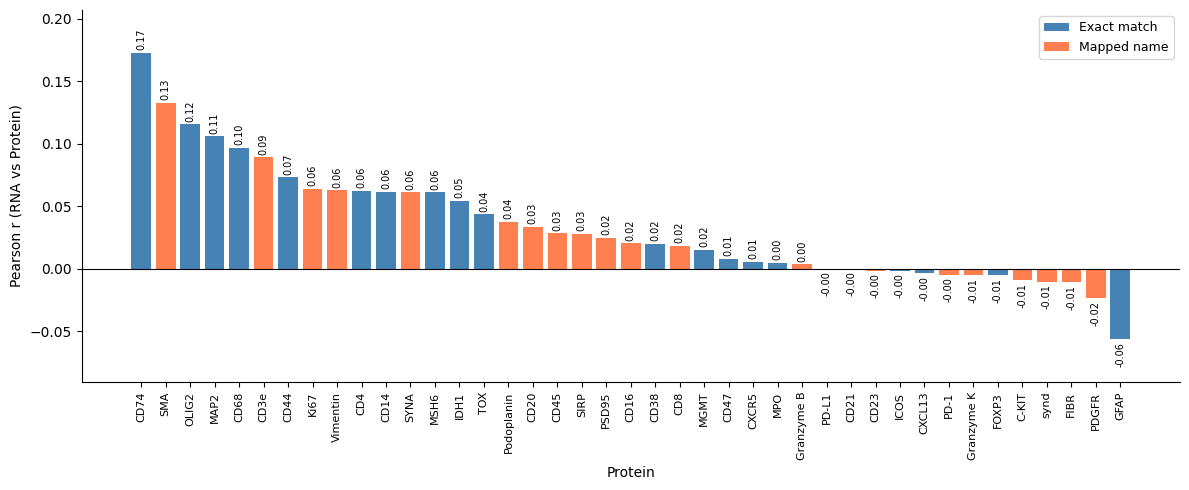

In [14]:
pairs = rna_protein_pairs

results = []

for pro_marker, rna_gene in pairs:
    rna_idx = list(rna.var_names).index(rna_gene)
    pro_idx = list(pro.var_names).index(pro_marker)

    rna_expr = rna.X[:, rna_idx]
    pro_expr = pro.X[:, pro_idx]
    if sp.issparse(rna_expr): rna_expr = rna_expr.toarray().flatten()
    if sp.issparse(pro_expr): pro_expr = pro_expr.toarray().flatten()

    # match bins by barcode
    shared = rna.obs_names.intersection(pro.obs_names)
    rna_vals = rna_expr[rna.obs_names.isin(shared)]
    pro_vals = pro_expr[pro.obs_names.isin(shared)]

    r, p = pearsonr(rna_vals, pro_vals)
    is_exact = rna_gene == pro_marker

    results.append({
        "gene":        f"{rna_gene}",
        "protein":     f"{pro_marker}",
        "r":           r,
        "p":           p,
        "exact_match": is_exact
    })

# sort by correlation strength
results_df = pd.DataFrame(results).sort_values("r", ascending=False)

# Plot
colours = ["steelblue" if exact else "coral"
           for exact in results_df["exact_match"]]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(results_df)), results_df["r"], color=colours)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, r in zip(bars, results_df["r"]):
    y = bar.get_height()

    offset = 0.002  # adjust as needed

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        y + offset if y >= 0 else y - offset,
        f"{r:.2f}",
        ha="center",
        va="bottom" if y >= 0 else "top",
        rotation=90,
        fontsize=7
    )

ax.set_xticks(range(len(results_df)))
ax.set_xticklabels(results_df['protein'], rotation=90, ha="center", fontsize=8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Protein")
ax.set_ylabel("Pearson r (RNA vs Protein)")
#ax.set_title("RNA–Protein correlation across matched pairs")

ax.margins(y=0.15)

# legend for colours
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="steelblue", label="Exact match"),
    Patch(facecolor="coral", label="Mapped name")]

ax.legend(handles=legend_elements, fontsize=9, loc="upper right")

plt.tight_layout()
plt.savefig("correlation.png", dpi=150)
plt.show()


# Protein distribution
- to determine preprocessing steps.

In [17]:
# protein data - pre-normalisation
X = pro.X.toarray() if hasattr(pro.X, "toarray") else np.asarray(pro.X)
X = np.nan_to_num(X.astype(float))

marker_stats = pd.DataFrame({
    "marker": pro.var_names,
    "min": X.min(axis=0),
    "max": X.max(axis=0),
    "mean": X.mean(axis=0),
    "median": np.median(X, axis=0),
    "std": X.std(axis=0),
    "p1": np.percentile(X, 1, axis=0),
    "p99": np.percentile(X, 99, axis=0),
})
marker_stats["range"] = marker_stats["max"] - marker_stats["min"]
marker_stats["max_to_p99_ratio"] = marker_stats["max"] / marker_stats["p99"]  # large = outlier-driven tail

#marker_stats.sort_values("max_to_p99_ratio", ascending=False)

summary = marker_stats[["marker", "min", "median", "mean", "std", "p99", "max", "max_to_p99_ratio"]]
summary = summary.sort_values("max_to_p99_ratio", ascending=False)
summary.head(15)

,marker,min,median,mean,std,p99,max,max_to_p99_ratio
19,Podoplanin,0.000000,100.387873,130.310835,361.846892,462.713731,45583.152227,98.512642
10,PSD95,0.000000,127.123756,196.293177,416.086568,904.429382,58581.581501,64.771869
30,C-KIT,0.000000,280.129455,288.302793,223.842777,677.360973,40806.838423,60.243858
24,Granzyme B,0.000000,485.309499,493.880933,323.846415,1115.316145,43085.263211,38.630538
16,CD23,0.000000,357.894001,414.010602,377.420800,1364.272073,47981.645221,35.170144
34,PDGFR,0.000000,231.440834,230.743923,136.608872,497.042037,16698.258187,33.595263
37,CD8,0.000000,682.314240,686.158581,358.058679,1212.526798,36921.272956,30.449861
12,CD68,0.000000,397.939591,468.280056,561.933629,1487.854739,40995.105305,27.553164
32,TOX,0.000000,968.721383,968.409300,404.115770,1839.666483,38215.213626,20.772903
38,MGMT,80.550328,541.334450,595.741110,449.220996,1748.964633,33730.503870,19.285984


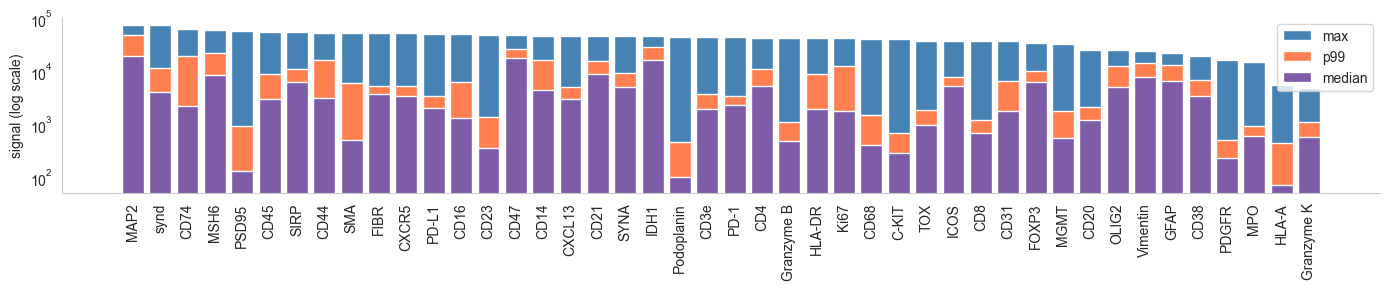

In [66]:
fig, ax = plt.subplots(figsize=(14, 3))
marker_stats_sorted = marker_stats.sort_values("max", ascending=False)
ax.bar(marker_stats_sorted["marker"], marker_stats_sorted["max"], alpha=1, color="steelblue", label="max")
ax.bar(marker_stats_sorted["marker"], marker_stats_sorted["p99"], alpha=1, color="coral", label="p99")
ax.bar(marker_stats_sorted["marker"], marker_stats_sorted["median"], alpha=1, color="#7D5BA6", label="median")
ax.set_yscale("log")
ax.yaxis.set_minor_locator(plt.NullLocator())
ax.set_ylabel("signal (log scale)")
ax.grid(False)
plt.xticks(rotation=90)
plt.yticks()
plt.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
#plt.title("Per-marker max / p99 / median (log scale)")
plt.savefig("per-protein_max_p99.png", dpi=150)
plt.tight_layout()

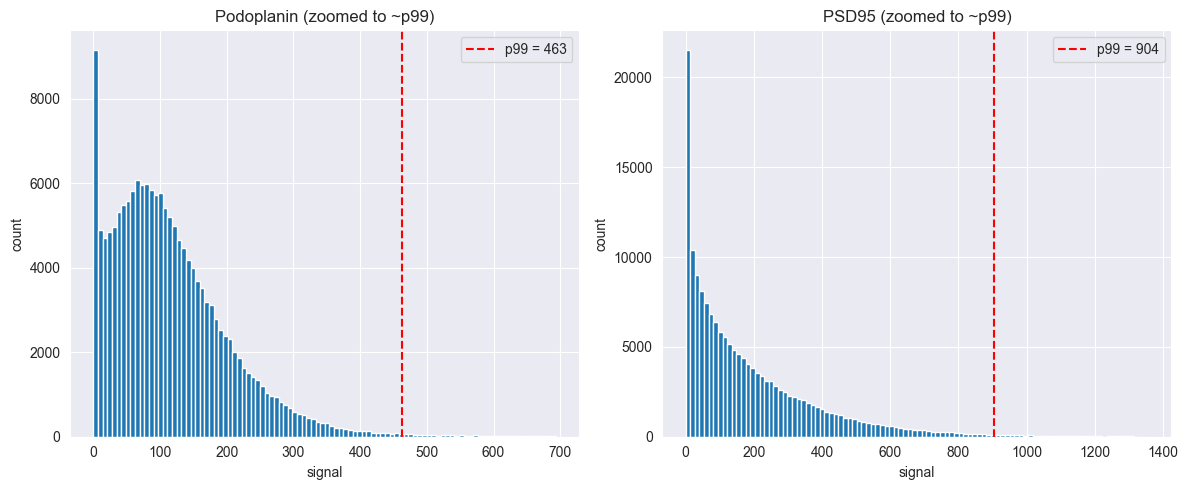

In [32]:
markers_to_plot = ["Podoplanin", "PSD95"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, marker in zip(axes, markers_to_plot):
    idx = pro.var_names.get_loc(marker)
    vals = X[:, idx]
    p99 = np.percentile(vals, 99)

    ax.hist(vals, bins=100, range=(0, p99 * 1.5))  # zoom to just past p99
    ax.axvline(p99, color="red", linestyle="--", label=f"p99 = {p99:,.0f}")
    ax.set_title(f"{marker} (zoomed to ~p99)")
    ax.set_xlabel("signal")
    ax.set_ylabel("count")
    ax.legend()

plt.tight_layout()
plt.savefig(f"p99_{markers_to_plot}", dpi=150)
plt.show()

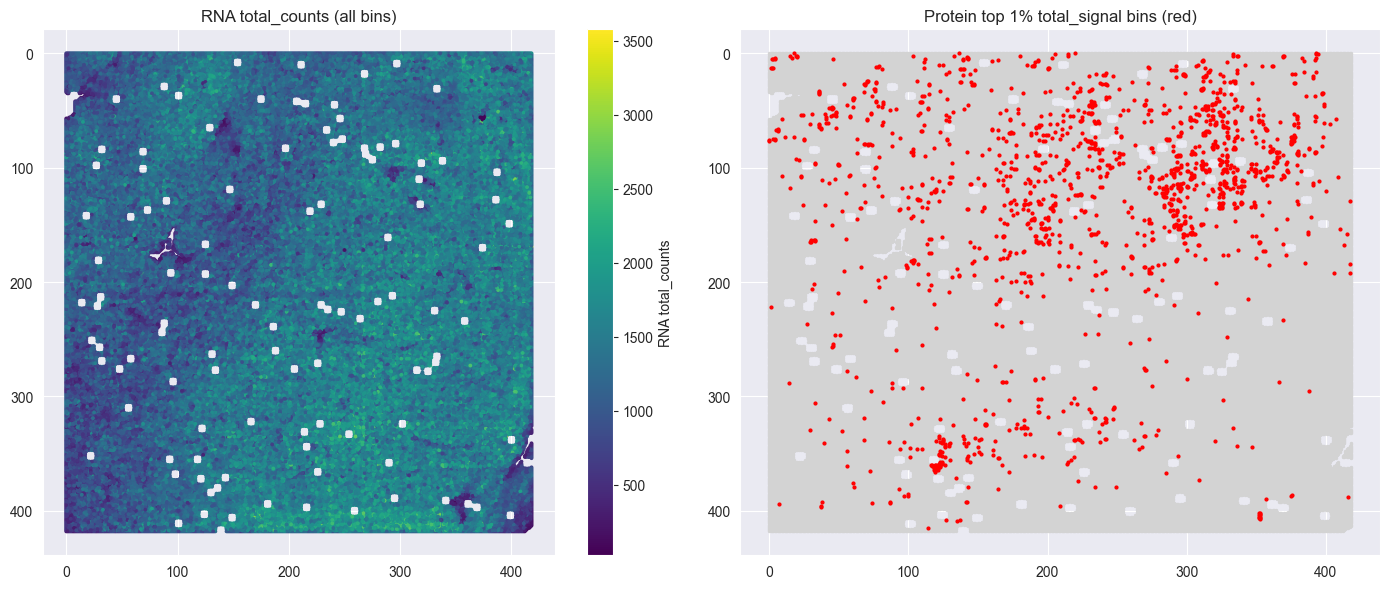

In [33]:
# spatial cross-comparison
# load RNA + copy spatial coordinates to protein data
rna_data = ad.read_h5ad("../data/train_rna.h5ad")

pro.obs["array_row"] = rna_data.obs["array_row"].values
pro.obs["array_col"] = rna_data.obs["array_col"].values

# protein total_signal
X = pro.X.toarray() if hasattr(pro.X, "toarray") else np.asarray(pro.X)
X = np.nan_to_num(X.astype(float))
pro.obs["total_signal"] = X.sum(axis=1)

# RNA QC metrics
rna_data.var["mt"] = rna_data.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(rna_data, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)

# top 1% protein outlier bins
high_signal_bins = pro.obs_names[
    pro.obs["total_signal"] > np.percentile(pro.obs["total_signal"], 99)
]

# spatial overlay: RNA total_counts vs. protein outlier bins
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc0 = axes[0].scatter(rna_data.obs["array_col"], rna_data.obs["array_row"],
                        c=rna_data.obs["total_counts"], s=3, cmap="viridis")
plt.colorbar(sc0, ax=axes[0], label="RNA total_counts")
axes[0].invert_yaxis()
axes[0].set_title("RNA total_counts (all bins)")

axes[1].scatter(pro.obs["array_col"], pro.obs["array_row"], c="lightgray", s=2)
axes[1].scatter(
    pro.obs.loc[high_signal_bins, "array_col"],
    pro.obs.loc[high_signal_bins, "array_row"],
    c="red", s=4
)
axes[1].invert_yaxis()
axes[1].set_title("Protein top 1% total_signal bins (red)")


plt.tight_layout()
plt.savefig("spatial_comparison.png", dpi=150)
plt.show()

# Spatial autocorrelation - for cross-validation split

sill=0.362  effective range=65.1 bins  practical range≈195.3 bins
corr at chosen radius (60): 0.152


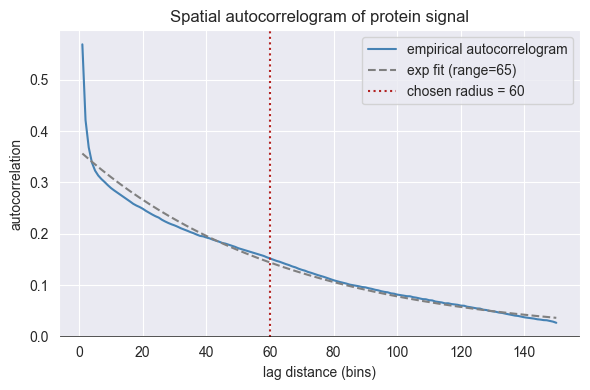

In [34]:
import numpy as np
import anndata as ad
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt


def spatial_autocorrelogram(row, col, value, max_lag=150):
    """
    Circular-lag spatial autocorrelogram on a square grid.
    row, col : integer grid coordinates (aligned with `value`)
    value    : 1D array of the target signal
    Returns: lags (bin units), corr (autocorrelation at each lag)
    """
    row0, col0 = row - row.min(), col - col.min()
    nrows, ncols = row0.max() + 1, col0.max() + 1

    grid = np.full((nrows, ncols), np.nan)
    grid[row0, col0] = value
    valid = ~np.isnan(grid)

    v = np.where(valid, grid - grid[valid].mean(), 0.0)
    var = v[valid].var()

    sums = {}
    for dx in range(-max_lag, max_lag + 1):
        for dy in range(-max_lag, max_lag + 1):
            dist = np.hypot(dx, dy)
            if dist == 0 or dist > max_lag:
                continue
            r1s, r1e = max(0, -dx), nrows - max(0, dx)
            c1s, c1e = max(0, -dy), ncols - max(0, dy)
            r2s, r2e = max(0, dx), nrows - max(0, -dx)
            c2s, c2e = max(0, dy), ncols - max(0, -dy)

            a, b = v[r1s:r1e, c1s:c1e], v[r2s:r2e, c2s:c2e]
            m = valid[r1s:r1e, c1s:c1e] & valid[r2s:r2e, c2s:c2e]
            if not m.any():
                continue

            key = round(dist)
            sums.setdefault(key, [0.0, 0])
            sums[key][0] += float(np.sum(a[m] * b[m]))
            sums[key][1] += int(m.sum())

    lags = np.array(sorted(sums.keys()))
    corr = np.array([sums[k][0] / sums[k][1] / var for k in lags])
    return lags, corr


def fit_range(lags, corr, p0_range=30):
    exp_decay = lambda d, sill, r: sill * np.exp(-d / r)
    popt, _ = curve_fit(exp_decay, lags, corr, p0=[corr[0], p0_range])
    sill, effective_range = popt
    return sill, effective_range, 3 * effective_range  # practical range


# run
protein = ad.read_h5ad("../data/train_pro.h5ad")
rna_data = ad.read_h5ad("../data/train_rna.h5ad")
protein.obs["array_row"] = rna_data.obs["array_row"].values
protein.obs["array_col"] = rna_data.obs["array_col"].values

target = np.asarray(protein.X.sum(axis=1)).ravel()

lags, corr = spatial_autocorrelogram(
    protein.obs["array_row"].to_numpy(),
    protein.obs["array_col"].to_numpy(),
    target,
    max_lag=150,
)
sill, eff_range, prac_range = fit_range(lags, corr)

chosen_radius = 60
print(f"sill={sill:.3f}  effective range={eff_range:.1f} bins  practical range≈{prac_range:.1f} bins")
print(f"corr at chosen radius ({chosen_radius}): {np.interp(chosen_radius, lags, corr):.3f}")

# figure: justifies the radius choice at a glance
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(lags, corr, color="steelblue", label="empirical autocorrelogram")
ax.plot(lags, sill * np.exp(-lags / eff_range), "--", color="gray", label=f"exp fit (range={eff_range:.0f})")
ax.axvline(chosen_radius, color="firebrick", linestyle=":", label=f"chosen radius = {chosen_radius}")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("lag distance (bins)")
ax.set_ylabel("autocorrelation")
ax.legend()
ax.set_title("Spatial autocorrelogram of protein signal")
plt.tight_layout()
plt.savefig("spatial_autocorrelogram.png", dpi=150)
plt.show()

Effective range: 60 bins. Add buffer to cross-validation split of 60 bins - spatial features added to rna data for XGBoost will calculate neighbourhood means from max 60 bin radius (no larger than buffer to prevent leakage).

In [25]:
N_NEIGHS = 4        # orthogonal (rook) neighbours on the square bin grid
N_PERMS = None       # None = fast analytic p-value; set e.g. 100 for permutation testing
RANDOM_SEED = 0

/Users/emilybeermann/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/emilybeermann/Library/Python/3.9/lib/python/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [44]:
# attach grid coordinates
def add_grid_coords(adata, row_col="array_row", col_col="array_col"):
    adata.obsm["spatial"] = adata.obs[[col_col, row_col]].values.astype(float)
    return adata

add_grid_coords(pro_pr)
add_grid_coords(rna_pr)
add_grid_coords(valid_rna_pr)

In [45]:
# spatial neighbour graphs
sq.gr.spatial_neighbors(rna_pr, coord_type="grid", n_neighs=N_NEIGHS)
sq.gr.spatial_neighbors(pro_pr, coord_type="grid", n_neighs=N_NEIGHS)

# average neighbours per bin should be close to N_NEIGHS
print("rna avg neighbours:", rna_pr.obsp["spatial_connectivities"].getnnz(axis=1).mean())
print("pro avg neighbours:", pro_pr.obsp["spatial_connectivities"].getnnz(axis=1).mean())

rna avg neighbours: 3.9605381921461493
pro avg neighbours: 3.9605381921461493


In [46]:
# moran's I for genes
sq.gr.spatial_autocorr(
    rna_pr, mode="moran", genes=rna_pr.var_names,
    n_perms=N_PERMS, n_jobs=-1, seed=RANDOM_SEED,
)
moran_genes = rna_pr.uns["moranI"].copy().rename(columns={"I": "moran_i"})
#moran_genes.to_csv("moran_i_genes_train.csv")
moran_genes.head()

/Users/emilybeermann/Library/Python/3.9/lib/python/site-packages/scanpy/metrics/_common.py:62: UserWarning: 29 variables were constant, will return nan for these.
  warnings.warn(


,moran_i,pval_norm,var_norm,pval_norm_fdr_bh
IGHM,0.573639,0.0,0.000003,0.0
IGKC,0.563026,0.0,0.000003,0.0
IGHG1,0.556932,0.0,0.000003,0.0
CRYAB,0.539354,0.0,0.000003,0.0
COL1A1,0.478445,0.0,0.000003,0.0


In [47]:
# moran's I for proteins
sq.gr.spatial_autocorr(
    pro_pr, mode="moran", genes=pro_pr.var_names,
    n_perms=N_PERMS, n_jobs=-1, seed=RANDOM_SEED,
)
moran_proteins = pro_pr.uns["moranI"].copy().rename(columns={"I": "moran_i"})
moran_proteins.to_csv("moran_i_proteins_train.csv")
moran_proteins.sort_values("moran_i", ascending=False)

,moran_i,pval_norm,var_norm,pval_norm_fdr_bh
synd,0.820319,0.0,0.000003,0.0
Granzyme B,0.806414,0.0,0.000003,0.0
MPO,0.804622,0.0,0.000003,0.0
CD21,0.791085,0.0,0.000003,0.0
MAP2,0.786607,0.0,0.000003,0.0
TOX,0.782652,0.0,0.000003,0.0
CD44,0.770101,0.0,0.000003,0.0
GFAP,0.767942,0.0,0.000003,0.0
Granzyme K,0.766684,0.0,0.000003,0.0
PDGFR,0.765799,0.0,0.000003,0.0


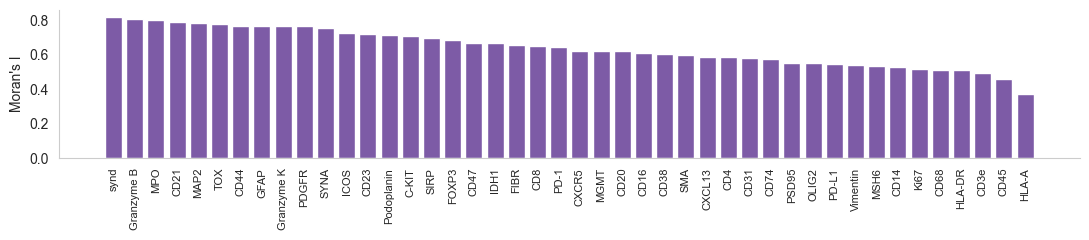

In [62]:
# protein moran I statistics
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(11, 2.5))

mp_sorted = moran_proteins.sort_values("moran_i", ascending=False)
ax.bar(range(len(mp_sorted)), mp_sorted["moran_i"], color="#7D5BA6")
ax.set_xticks(range(len(mp_sorted)))
ax.set_xticklabels(mp_sorted.index, rotation=90, fontsize=8)
ax.set_ylabel("Moran's I")
#ax.set_title(f"Protein-level spatial autocorrelation (n={len(mp_sorted)} proteins)")
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("moran_i_proteins.png", dpi=220, bbox_inches="tight")
plt.show()